In [1]:
!pip -q install monai pillow

from pathlib import Path
import zipfile
import json
import random
import shutil
from datetime import datetime

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

WORK_ROOT = Path("/kaggle/working")
INPUT_ROOT = Path("/kaggle/input")

PROJECT_ROOT = WORK_ROOT / "project_rooting_week4"

MANIFEST_DIR = PROJECT_ROOT / "data-manifests"
DERIVED_DIR = PROJECT_ROOT / "derived"
QC_DIR = PROJECT_ROOT / "qc"
EXPORT_DIR = PROJECT_ROOT / "exports"

AUG_PAIR_DIR = DERIVED_DIR / "augmented_pairs"

for directory in [
    PROJECT_ROOT,
    MANIFEST_DIR,
    DERIVED_DIR,
    QC_DIR,
    EXPORT_DIR,
    AUG_PAIR_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Week 4 root:", PROJECT_ROOT)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.5 MB/s eta 0:00:00
Week 4 root: /kaggle/working/project_rooting_week4


In [3]:
from pathlib import Path
import zipfile
import pandas as pd

INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")

print("=== INPUT TREE CHECK ===")

all_paths = list(INPUT_ROOT.rglob("*"))
print("Total input paths:", len(all_paths))

for path in all_paths[:80]:
    print(path)

print("\n=== SEARCHING FOR WEEK 3 ZIP ===")
zip_files = list(INPUT_ROOT.rglob("*.zip"))

for z in zip_files:
    print("ZIP:", z)

print("ZIP count:", len(zip_files))

print("\n=== SEARCHING FOR WEEK 3 CSV DIRECTLY ===")
csv_files = list(INPUT_ROOT.rglob("week3_preprocessed_pairs.csv"))

for c in csv_files:
    print("CSV:", c)

print("CSV count:", len(csv_files))


# CASE 1: Kaggle mounted the ZIP as a ZIP file
if zip_files:
    week3_zip_candidates = [
        z for z in zip_files
        if "week3_full_outputs_for_week4" in z.name
    ]

    if week3_zip_candidates:
        WEEK3_ZIP = week3_zip_candidates[0]
    else:
        WEEK3_ZIP = zip_files[0]

    EXTRACT_DIR = WORK_ROOT / "week3_input"
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(WEEK3_ZIP, "r") as zip_file:
        zip_file.extractall(EXTRACT_DIR)

    print("\nSelected ZIP:", WEEK3_ZIP)
    print("Extracted to:", EXTRACT_DIR)

    pairs_files = list(EXTRACT_DIR.rglob("week3_preprocessed_pairs.csv"))

    if not pairs_files:
        raise FileNotFoundError(
            "ZIP was extracted, but week3_preprocessed_pairs.csv was not found."
        )

    WEEK3_PAIRS_CSV = pairs_files[0]
    WEEK3_ROOT = WEEK3_PAIRS_CSV.parent.parent


# CASE 2: Kaggle auto-extracted the input already
elif csv_files:
    WEEK3_PAIRS_CSV = csv_files[0]
    WEEK3_ROOT = WEEK3_PAIRS_CSV.parent.parent

    print("\nUsing auto-extracted Week 3 input.")


# CASE 3: Input visible in UI but kernel cannot see it yet
else:
    raise FileNotFoundError(
        "Kaggle UI shows the input, but the kernel cannot see the ZIP or CSV yet. "
        "Click refresh near the input panel or Restart Session, then rerun this cell."
    )


print("\n=== WEEK 3 INPUT RESOLVED ===")
print("Week 3 root:", WEEK3_ROOT)
print("Week 3 pairs CSV:", WEEK3_PAIRS_CSV)

=== INPUT TREE CHECK ===
Total input paths: 263
/kaggle/input/datasets
/kaggle/input/datasets/omneyasaeid
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/README.md
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/exports
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/qc
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/derived
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/data-manifests
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/exports/week3_preprocessing_policy.json
/kaggle/input/datasets/omneyasaeid/week3-full-outputs-for-week4-zip/project_rooting_week3/exports/week3_monai_da

In [4]:
import pandas as pd
from pathlib import Path

week3_pairs_df = pd.read_csv(WEEK3_PAIRS_CSV)

print("=== WEEK 3 PAIRS ===")
print("Rows:", len(week3_pairs_df))
print("Patients:", week3_pairs_df["PatientID"].nunique())
print("Columns:")
print(week3_pairs_df.columns.tolist())

display(week3_pairs_df.head())

=== WEEK 3 PAIRS ===
Rows: 77
Patients: 10
Columns:
['pair_id', 'PatientID', 'dataset_split', 'source_panel_a_path', 'source_panel_b_path', 'panel_a_preprocessed_path', 'panel_b_preprocessed_path', 'target_size', 'split_confidence_score', 'split_confidence_tier', 'split_validation_status', 'pairing_status', 'semantic_review_status']


,pair_id,PatientID,dataset_split,source_panel_a_path,source_panel_b_path,panel_a_preprocessed_path,panel_b_preprocessed_path,target_size,split_confidence_score,split_confidence_tier,split_validation_status,pairing_status,semantic_review_status
0,W2PAIR_0001,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.965447,high,accepted_manual_review,candidate_not_ground_truth,manual_candidate_level
1,W2PAIR_0002,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.929760,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified
2,W2PAIR_0003,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.968587,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified
3,W2PAIR_0004,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.968558,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified
4,W2PAIR_0005,LiverUS-102,train,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/input/datasets/omneyasaeid/week2-input...,/kaggle/working/project_rooting_week3/derived/...,/kaggle/working/project_rooting_week3/derived/...,256,0.900105,high,accepted_auto_high_confidence,candidate_not_ground_truth,not_manually_verified


In [6]:
def resolve_week3_path(value):
    value = str(value)
    path = Path(value)

    if path.exists():
        return path

    filename = path.name

    for root in [WEEK3_ROOT, INPUT_ROOT, WORK_ROOT]:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]

    return path


week3_pairs_df["panel_a_path_resolved"] = week3_pairs_df[
    "panel_a_preprocessed_path"
].map(resolve_week3_path)

week3_pairs_df["panel_b_path_resolved"] = week3_pairs_df[
    "panel_b_preprocessed_path"
].map(resolve_week3_path)

week3_pairs_df["panel_a_exists"] = week3_pairs_df[
    "panel_a_path_resolved"
].map(lambda p: Path(p).exists())

week3_pairs_df["panel_b_exists"] = week3_pairs_df[
    "panel_b_path_resolved"
].map(lambda p: Path(p).exists())

print("Panel A:", int(week3_pairs_df["panel_a_exists"].sum()), "/", len(week3_pairs_df))
print("Panel B:", int(week3_pairs_df["panel_b_exists"].sum()), "/", len(week3_pairs_df))

if not (
    week3_pairs_df["panel_a_exists"].all()
    and
    week3_pairs_df["panel_b_exists"].all()
):
    raise FileNotFoundError(
        "Some Week 3 preprocessed images are missing."
    )

print("Week 3 images resolved successfully ")

Panel A: 77 / 77
Panel B: 77 / 77
Week 3 images resolved successfully 


In [7]:
NUM_AUG_PER_TRAIN_PAIR = 3
TARGET_SIZE = 256

AUGMENTATION_POLICY = {
    "week": "Week 4",
    "focus": "ultrasound_specific_augmentation_and_qc",
    "input": "Week 3 preprocessed paired panel candidates",
    "apply_to": "training_split_only",
    "validation_and_test": "kept_original_only",
    "num_augmented_versions_per_training_pair": NUM_AUG_PER_TRAIN_PAIR,
    "spatial_transforms": {
        "small_rotation_degrees": [-7, 7],
        "small_translation_pixels": [-8, 8],
        "small_zoom_scale": [0.95, 1.05],
        "horizontal_flip": "disabled_by_default",
    },
    "intensity_transforms": {
        "gamma": [0.85, 1.15],
        "gain": [0.90, 1.10],
        "offset": [-10, 10],
        "speckle_noise_sigma": [0.00, 0.05],
    },
    "paired_transform_consistency": (
        "The same spatial transform parameters are applied to panel A and panel B "
        "within the same pair."
    ),
    "scientific_boundary": (
        "Augmentation improves robustness of the AI-ready dataset but does not create "
        "clinical labels, confirmed B-mode/CEUS labels, stiffness estimates, or "
        "biomechanical parameters."
    ),
}

with open(
    EXPORT_DIR / "week4_augmentation_policy.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(AUGMENTATION_POLICY, f, indent=2)

print(json.dumps(AUGMENTATION_POLICY, indent=2))

{
  "week": "Week 4",
  "focus": "ultrasound_specific_augmentation_and_qc",
  "input": "Week 3 preprocessed paired panel candidates",
  "apply_to": "training_split_only",
  "validation_and_test": "kept_original_only",
  "num_augmented_versions_per_training_pair": 3,
  "spatial_transforms": {
    "small_rotation_degrees": [
      -7,
      7
    ],
    "small_translation_pixels": [
      -8,
      8
    ],
    "small_zoom_scale": [
      0.95,
      1.05
    ],
    "horizontal_flip": "disabled_by_default"
  },
  "intensity_transforms": {
    "gamma": [
      0.85,
      1.15
    ],
    "gain": [
      0.9,
      1.1
    ],
    "offset": [
      -10,
      10
    ],
    "speckle_noise_sigma": [
      0.0,
      0.05
    ]
  },
  "paired_transform_consistency": "The same spatial transform parameters are applied to panel A and panel B within the same pair.",
  "scientific_boundary": "Augmentation improves robustness of the AI-ready dataset but does not create clinical labels, confirmed B-m

In [8]:
def center_zoom_uint8(image_array, scale, fill_value=0):
    image = Image.fromarray(image_array).convert("L")
    width, height = image.size

    new_width = int(round(width * scale))
    new_height = int(round(height * scale))

    resized = image.resize(
        (new_width, new_height),
        resample=Image.BILINEAR,
    )

    canvas = Image.new(
        "L",
        (width, height),
        color=fill_value,
    )

    if scale >= 1:
        left = (new_width - width) // 2
        top = (new_height - height) // 2
        cropped = resized.crop((left, top, left + width, top + height))
        return np.asarray(cropped)

    else:
        left = (width - new_width) // 2
        top = (height - new_height) // 2
        canvas.paste(resized, (left, top))
        return np.asarray(canvas)


def translate_uint8(image_array, tx, ty, fill_value=0):
    image = Image.fromarray(image_array).convert("L")
    width, height = image.size

    canvas = Image.new(
        "L",
        (width, height),
        color=fill_value,
    )

    canvas.paste(image, (int(tx), int(ty)))

    return np.asarray(canvas)


def apply_spatial_transform(image_array, angle, scale, tx, ty):
    arr = center_zoom_uint8(
        image_array,
        scale=scale,
        fill_value=0,
    )

    image = Image.fromarray(arr).convert("L")

    image = image.rotate(
        angle,
        resample=Image.BILINEAR,
        fillcolor=0,
    )

    arr = np.asarray(image)

    arr = translate_uint8(
        arr,
        tx=tx,
        ty=ty,
        fill_value=0,
    )

    return arr


def apply_intensity_transform(image_array, gamma, gain, offset, speckle_sigma, rng):
    arr = image_array.astype(np.float32) / 255.0

    arr = np.clip(arr, 0, 1)
    arr = arr ** gamma
    arr = arr * gain + (offset / 255.0)

    if speckle_sigma > 0:
        noise = rng.normal(
            loc=0.0,
            scale=speckle_sigma,
            size=arr.shape,
        )
        arr = arr + arr * noise

    arr = np.clip(arr, 0, 1)
    arr = (arr * 255).astype(np.uint8)

    return arr


def sample_augmentation_params(seed):
    rng = np.random.default_rng(seed)

    params = {
        "angle": float(rng.uniform(-7, 7)),
        "scale": float(rng.uniform(0.95, 1.05)),
        "tx": int(rng.integers(-8, 9)),
        "ty": int(rng.integers(-8, 9)),
        "gamma": float(rng.uniform(0.85, 1.15)),
        "gain": float(rng.uniform(0.90, 1.10)),
        "offset": float(rng.uniform(-10, 10)),
        "speckle_sigma": float(rng.uniform(0.00, 0.05)),
    }

    return params


def augment_pair(panel_a_path, panel_b_path, output_a_path, output_b_path, seed):
    rng = np.random.default_rng(seed)

    params = sample_augmentation_params(seed)

    panel_a = np.asarray(
        Image.open(panel_a_path).convert("L")
    )

    panel_b = np.asarray(
        Image.open(panel_b_path).convert("L")
    )

    # Same spatial transform for both panels
    panel_a_spatial = apply_spatial_transform(
        panel_a,
        angle=params["angle"],
        scale=params["scale"],
        tx=params["tx"],
        ty=params["ty"],
    )

    panel_b_spatial = apply_spatial_transform(
        panel_b,
        angle=params["angle"],
        scale=params["scale"],
        tx=params["tx"],
        ty=params["ty"],
    )

    # Same intensity parameters, independent noise draw
    panel_a_aug = apply_intensity_transform(
        panel_a_spatial,
        gamma=params["gamma"],
        gain=params["gain"],
        offset=params["offset"],
        speckle_sigma=params["speckle_sigma"],
        rng=rng,
    )

    panel_b_aug = apply_intensity_transform(
        panel_b_spatial,
        gamma=params["gamma"],
        gain=params["gain"],
        offset=params["offset"],
        speckle_sigma=params["speckle_sigma"],
        rng=rng,
    )

    output_a_path.parent.mkdir(parents=True, exist_ok=True)
    output_b_path.parent.mkdir(parents=True, exist_ok=True)

    Image.fromarray(panel_a_aug).save(output_a_path)
    Image.fromarray(panel_b_aug).save(output_b_path)

    metrics = {
        "seed": seed,
        **params,
        "panel_a_output_min": int(panel_a_aug.min()),
        "panel_a_output_max": int(panel_a_aug.max()),
        "panel_a_output_mean": float(panel_a_aug.mean()),
        "panel_a_output_std": float(panel_a_aug.std()),
        "panel_b_output_min": int(panel_b_aug.min()),
        "panel_b_output_max": int(panel_b_aug.max()),
        "panel_b_output_mean": float(panel_b_aug.mean()),
        "panel_b_output_std": float(panel_b_aug.std()),
    }

    return metrics

In [9]:
train_df = week3_pairs_df[
    week3_pairs_df["dataset_split"] == "train"
].copy()

val_df = week3_pairs_df[
    week3_pairs_df["dataset_split"] == "val"
].copy()

test_df = week3_pairs_df[
    week3_pairs_df["dataset_split"] == "test"
].copy()

print("Train pairs:", len(train_df))
print("Val pairs:", len(val_df))
print("Test pairs:", len(test_df))

augmented_rows = []
augmentation_qc_rows = []

# 1. Keep all originals
for _, row in week3_pairs_df.iterrows():
    augmented_rows.append({
        "item_id": f"{row['pair_id']}__original",
        "pair_id": row["pair_id"],
        "PatientID": row["PatientID"],
        "dataset_split": row["dataset_split"],
        "augmentation_status": "original",
        "augmentation_index": 0,
        "panel_a_path": str(row["panel_a_path_resolved"]),
        "panel_b_path": str(row["panel_b_path_resolved"]),
        "source_pair_id": row["pair_id"],
        "is_augmented": False,
    })

# 2. Augment train only
for _, row in train_df.iterrows():
    pair_id = row["pair_id"]
    patient_id = row["PatientID"]

    for aug_index in range(1, NUM_AUG_PER_TRAIN_PAIR + 1):
        aug_seed = abs(hash((pair_id, aug_index, SEED))) % (2**32)

        output_dir = (
            AUG_PAIR_DIR
            / "train"
            / str(patient_id)
            / str(pair_id)
            / f"aug_{aug_index:02d}"
        )

        output_a = output_dir / "panel_a_augmented.png"
        output_b = output_dir / "panel_b_augmented.png"

        metrics = augment_pair(
            panel_a_path=Path(row["panel_a_path_resolved"]),
            panel_b_path=Path(row["panel_b_path_resolved"]),
            output_a_path=output_a,
            output_b_path=output_b,
            seed=aug_seed,
        )

        item_id = f"{pair_id}__aug_{aug_index:02d}"

        augmented_rows.append({
            "item_id": item_id,
            "pair_id": pair_id,
            "PatientID": patient_id,
            "dataset_split": "train",
            "augmentation_status": "augmented",
            "augmentation_index": aug_index,
            "panel_a_path": str(output_a),
            "panel_b_path": str(output_b),
            "source_pair_id": pair_id,
            "is_augmented": True,
        })

        augmentation_qc_rows.append({
            "item_id": item_id,
            "pair_id": pair_id,
            "PatientID": patient_id,
            "dataset_split": "train",
            "augmentation_index": aug_index,
            "panel_a_path": str(output_a),
            "panel_b_path": str(output_b),
            **metrics,
        })

week4_augmented_df = pd.DataFrame(augmented_rows)
week4_aug_qc_df = pd.DataFrame(augmentation_qc_rows)

AUGMENTED_MANIFEST_PATH = (
    MANIFEST_DIR / "week4_augmented_pairs_manifest.csv"
)

AUGMENTATION_QC_PATH = (
    MANIFEST_DIR / "week4_augmentation_qc_metrics.csv"
)

week4_augmented_df.to_csv(
    AUGMENTED_MANIFEST_PATH,
    index=False,
)

week4_aug_qc_df.to_csv(
    AUGMENTATION_QC_PATH,
    index=False,
)

print("=== WEEK 4 AUGMENTATION COMPLETE ===")
print("Original total:", len(week3_pairs_df))
print("Train originals:", len(train_df))
print("Augmented train items:", len(week4_aug_qc_df))
print("Final manifest rows:", len(week4_augmented_df))

display(week4_augmented_df.head())
display(week4_aug_qc_df.head())

Train pairs: 43
Val pairs: 22
Test pairs: 12
=== WEEK 4 AUGMENTATION COMPLETE ===
Original total: 77
Train originals: 43
Augmented train items: 129
Final manifest rows: 206


,item_id,pair_id,PatientID,dataset_split,augmentation_status,augmentation_index,panel_a_path,panel_b_path,source_pair_id,is_augmented
0,W2PAIR_0001__original,W2PAIR_0001,LiverUS-102,train,original,0,/kaggle/input/datasets/omneyasaeid/week3-full-...,/kaggle/input/datasets/omneyasaeid/week3-full-...,W2PAIR_0001,False
1,W2PAIR_0002__original,W2PAIR_0002,LiverUS-102,train,original,0,/kaggle/input/datasets/omneyasaeid/week3-full-...,/kaggle/input/datasets/omneyasaeid/week3-full-...,W2PAIR_0002,False
2,W2PAIR_0003__original,W2PAIR_0003,LiverUS-102,train,original,0,/kaggle/input/datasets/omneyasaeid/week3-full-...,/kaggle/input/datasets/omneyasaeid/week3-full-...,W2PAIR_0003,False
3,W2PAIR_0004__original,W2PAIR_0004,LiverUS-102,train,original,0,/kaggle/input/datasets/omneyasaeid/week3-full-...,/kaggle/input/datasets/omneyasaeid/week3-full-...,W2PAIR_0004,False
4,W2PAIR_0005__original,W2PAIR_0005,LiverUS-102,train,original,0,/kaggle/input/datasets/omneyasaeid/week3-full-...,/kaggle/input/datasets/omneyasaeid/week3-full-...,W2PAIR_0005,False


,item_id,pair_id,PatientID,dataset_split,augmentation_index,panel_a_path,panel_b_path,seed,angle,scale,...,offset,speckle_sigma,panel_a_output_min,panel_a_output_max,panel_a_output_mean,panel_a_output_std,panel_b_output_min,panel_b_output_max,panel_b_output_mean,panel_b_output_std
0,W2PAIR_0001__aug_01,W2PAIR_0001,LiverUS-102,train,1,/kaggle/working/project_rooting_week4/derived/...,/kaggle/working/project_rooting_week4/derived/...,3080353866,-3.169860,0.959878,...,6.502934,0.030134,5,255,89.058289,70.755481,5,255,50.184479,64.836055
1,W2PAIR_0001__aug_02,W2PAIR_0001,LiverUS-102,train,2,/kaggle/working/project_rooting_week4/derived/...,/kaggle/working/project_rooting_week4/derived/...,156789339,-5.015576,0.953990,...,7.714340,0.043900,6,255,92.293533,73.199308,6,255,52.754883,66.635241
2,W2PAIR_0001__aug_03,W2PAIR_0001,LiverUS-102,train,3,/kaggle/working/project_rooting_week4/derived/...,/kaggle/working/project_rooting_week4/derived/...,3802118376,-2.981300,0.981900,...,-8.164457,0.044929,0,255,62.608643,55.358438,0,254,31.702377,51.522588
3,W2PAIR_0002__aug_01,W2PAIR_0002,LiverUS-102,train,1,/kaggle/working/project_rooting_week4/derived/...,/kaggle/working/project_rooting_week4/derived/...,3005809900,-2.417631,1.042581,...,4.969115,0.002277,4,255,96.280670,62.940031,4,255,52.951859,63.501362
4,W2PAIR_0002__aug_02,W2PAIR_0002,LiverUS-102,train,2,/kaggle/working/project_rooting_week4/derived/...,/kaggle/working/project_rooting_week4/derived/...,1194385833,-1.584738,1.005418,...,2.907688,0.045165,2,255,71.486221,55.971511,2,255,38.439102,53.133165


In [10]:
week4_augmented_df["panel_a_exists"] = week4_augmented_df[
    "panel_a_path"
].map(lambda p: Path(p).exists())

week4_augmented_df["panel_b_exists"] = week4_augmented_df[
    "panel_b_path"
].map(lambda p: Path(p).exists())

print("Panel A exists:", int(week4_augmented_df["panel_a_exists"].sum()), "/", len(week4_augmented_df))
print("Panel B exists:", int(week4_augmented_df["panel_b_exists"].sum()), "/", len(week4_augmented_df))

missing_df = week4_augmented_df[
    ~(
        week4_augmented_df["panel_a_exists"]
        &
        week4_augmented_df["panel_b_exists"]
    )
]

display(missing_df.head())

if len(missing_df) > 0:
    raise FileNotFoundError("Some augmented/original image paths are missing.")

Panel A exists: 206 / 206
Panel B exists: 206 / 206


,item_id,pair_id,PatientID,dataset_split,augmentation_status,augmentation_index,panel_a_path,panel_b_path,source_pair_id,is_augmented,panel_a_exists,panel_b_exists


In [12]:
week4_monai_datalist = {
    "name": "Project Rooting Week 4 Augmented Ultrasound Dataset",
    "stage": "week4_augmentation_and_final_qc",
    "source": "Week 3 preprocessed paired panel candidates",
    "augmentation_policy": AUGMENTATION_POLICY,
    "pairing_semantics": (
        "Panel A and Panel B are candidate paired panels derived from "
        "validated intra-DICOM split cases. They are not confirmed "
        "ground-truth B-mode/CEUS modality labels."
    ),
    "splits": {
        "training": [],
        "validation": [],
        "test": [],
    },
}

split_key_map = {
    "train": "training",
    "val": "validation",
    "test": "test",
}

for _, row in week4_augmented_df.iterrows():
    item = {
        "item_id": row["item_id"],
        "pair_id": row["pair_id"],
        "patient_id": row["PatientID"],
        "panel_a": row["panel_a_path"],
        "panel_b": row["panel_b_path"],
        "augmentation_status": row["augmentation_status"],
        "augmentation_index": int(row["augmentation_index"]),
        "is_augmented": bool(row["is_augmented"]),
    }

    split_key = split_key_map[row["dataset_split"]]
    week4_monai_datalist["splits"][split_key].append(item)

WEEK4_MONAI_DATALIST_PATH = (
    EXPORT_DIR / "week4_monai_augmented_datalist.json"
)

with open(
    WEEK4_MONAI_DATALIST_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(week4_monai_datalist, f, indent=2)

print("=== WEEK 4 MONAI DATALIST ===")
print("Training:", len(week4_monai_datalist["splits"]["training"]))
print("Validation:", len(week4_monai_datalist["splits"]["validation"]))
print("Test:", len(week4_monai_datalist["splits"]["test"]))
print("Saved:", WEEK4_MONAI_DATALIST_PATH)

=== WEEK 4 MONAI DATALIST ===
Training: 172
Validation: 22
Test: 12
Saved: /kaggle/working/project_rooting_week4/exports/week4_monai_augmented_datalist.json


In [13]:
from monai.data import Dataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
)

smoke_items = week4_monai_datalist["splits"]["training"][:5]

smoke_transform = Compose([
    LoadImaged(
        keys=["panel_a", "panel_b"],
        image_only=True,
    ),
    EnsureChannelFirstd(
        keys=["panel_a", "panel_b"],
        channel_dim="no_channel",
    ),
    ScaleIntensityd(
        keys=["panel_a", "panel_b"],
    ),
])

monai_smoke_success = True
monai_smoke_error = ""

try:
    smoke_dataset = Dataset(
        data=smoke_items,
        transform=smoke_transform,
    )

    sample = smoke_dataset[0]

    print("=== MONAI SMOKE TEST ===")
    print("Item ID:", sample["item_id"])
    print("Panel A shape:", tuple(sample["panel_a"].shape))
    print("Panel B shape:", tuple(sample["panel_b"].shape))
    print("Panel A range:", float(sample["panel_a"].min()), float(sample["panel_a"].max()))
    print("Panel B range:", float(sample["panel_b"].min()), float(sample["panel_b"].max()))
    print("MONAI smoke test: PASS ")

except Exception as error:
    monai_smoke_success = False
    monai_smoke_error = str(error)

    print("MONAI smoke test: FAIL ")
    print(monai_smoke_error)

=== MONAI SMOKE TEST ===
Item ID: W2PAIR_0001__original
Panel A shape: (1, 256, 256)
Panel B shape: (1, 256, 256)
Panel A range: 0.0 1.0
Panel B range: 0.0 1.0
MONAI smoke test: PASS 


QC sheet: /kaggle/working/project_rooting_week4/qc/week4_augmented_pair_contact_sheet.png


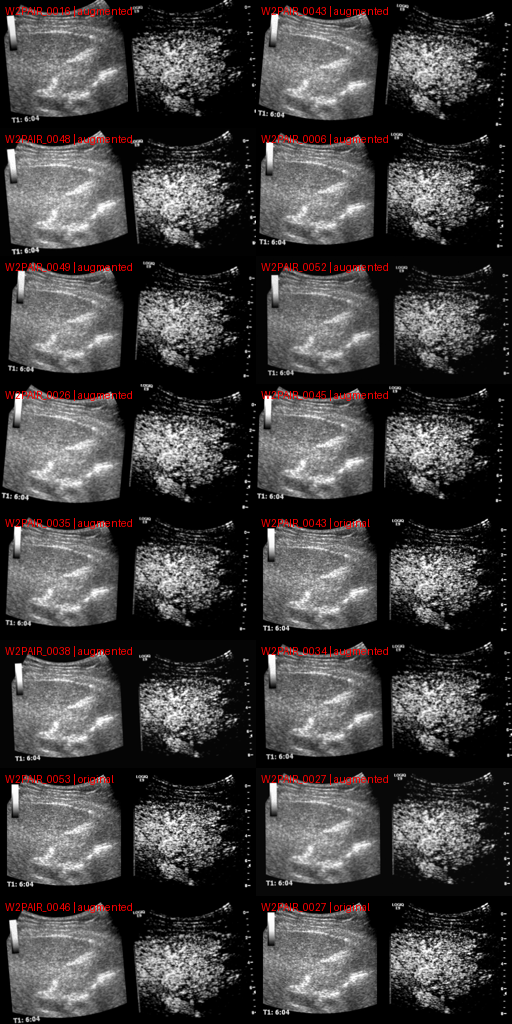

In [14]:
def make_week4_qc_sheet(dataframe, output_path, max_items=12, tile_size=128):
    sample_df = (
        dataframe
        .sample(
            n=min(max_items, len(dataframe)),
            random_state=SEED,
        )
        .reset_index(drop=True)
    )

    rows = []

    for _, row in sample_df.iterrows():
        panel_a = Image.open(row["panel_a_path"]).convert("L").resize((tile_size, tile_size))
        panel_b = Image.open(row["panel_b_path"]).convert("L").resize((tile_size, tile_size))

        combined = Image.new(
            "L",
            (tile_size * 2, tile_size),
            color=0,
        )

        combined.paste(panel_a, (0, 0))
        combined.paste(panel_b, (tile_size, 0))

        combined = combined.convert("RGB")
        draw = ImageDraw.Draw(combined)

        label = f"{row['pair_id']} | {row['augmentation_status']}"

        draw.text(
            (5, 5),
            label,
            fill=(255, 0, 0),
        )

        rows.append(combined)

    columns = 2
    n_rows = int(np.ceil(len(rows) / columns))

    sheet = Image.new(
        "RGB",
        (
            columns * tile_size * 2,
            n_rows * tile_size,
        ),
        color=(0, 0, 0),
    )

    for idx, img in enumerate(rows):
        x = (idx % columns) * tile_size * 2
        y = (idx // columns) * tile_size
        sheet.paste(img, (x, y))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(output_path)

    return output_path


WEEK4_QC_SHEET = QC_DIR / "week4_augmented_pair_contact_sheet.png"

make_week4_qc_sheet(
    dataframe=week4_augmented_df[
        week4_augmented_df["dataset_split"] == "train"
    ],
    output_path=WEEK4_QC_SHEET,
    max_items=16,
)

print("QC sheet:", WEEK4_QC_SHEET)
display(Image.open(WEEK4_QC_SHEET))

In [15]:
validation_tests = []

def add_test(name, passed, details):
    validation_tests.append({
        "test_name": name,
        "passed": bool(passed),
        "details": str(details),
    })


original_count = len(week3_pairs_df)
train_count = len(train_df)
expected_aug_count = train_count * NUM_AUG_PER_TRAIN_PAIR
expected_total = original_count + expected_aug_count

add_test(
    "original_week3_count_preserved",
    original_count == 77,
    f"original_count={original_count}",
)

add_test(
    "augmented_train_count_correct",
    len(week4_aug_qc_df) == expected_aug_count,
    f"{len(week4_aug_qc_df)} / {expected_aug_count}",
)

add_test(
    "final_manifest_count_correct",
    len(week4_augmented_df) == expected_total,
    f"{len(week4_augmented_df)} / {expected_total}",
)

add_test(
    "all_image_paths_exist",
    week4_augmented_df["panel_a_exists"].all()
    and
    week4_augmented_df["panel_b_exists"].all(),
    (
        f"A={int(week4_augmented_df['panel_a_exists'].sum())}, "
        f"B={int(week4_augmented_df['panel_b_exists'].sum())}"
    ),
)

def image_size_ok(path):
    return Image.open(path).size == (TARGET_SIZE, TARGET_SIZE)

all_sizes_ok = (
    week4_augmented_df["panel_a_path"].map(image_size_ok).all()
    and
    week4_augmented_df["panel_b_path"].map(image_size_ok).all()
)

add_test(
    "all_images_are_256x256",
    all_sizes_ok,
    f"target={TARGET_SIZE}x{TARGET_SIZE}",
)

patient_split_counts = (
    week4_augmented_df
    .groupby("PatientID")["dataset_split"]
    .nunique()
)

add_test(
    "no_patient_level_split_leakage",
    (patient_split_counts <= 1).all(),
    f"max_splits_per_patient={patient_split_counts.max()}",
)

val_test_augmented = week4_augmented_df[
    (week4_augmented_df["dataset_split"].isin(["val", "test"]))
    &
    (week4_augmented_df["is_augmented"] == True)
]

add_test(
    "validation_and_test_are_not_augmented",
    len(val_test_augmented) == 0,
    f"val_test_augmented_items={len(val_test_augmented)}",
)

datalist_total = (
    len(week4_monai_datalist["splits"]["training"])
    +
    len(week4_monai_datalist["splits"]["validation"])
    +
    len(week4_monai_datalist["splits"]["test"])
)

add_test(
    "monai_datalist_count_matches_manifest",
    datalist_total == len(week4_augmented_df),
    f"{datalist_total} / {len(week4_augmented_df)}",
)

add_test(
    "monai_loader_smoke_test",
    monai_smoke_success,
    "PASS" if monai_smoke_success else monai_smoke_error,
)

add_test(
    "qc_contact_sheet_exists",
    WEEK4_QC_SHEET.exists(),
    WEEK4_QC_SHEET,
)

validation_tests_df = pd.DataFrame(validation_tests)

week4_validation_pass = bool(
    validation_tests_df["passed"].all()
)

validation_report = {
    "week": "Week 4",
    "stage": "augmentation_and_final_dataset_qc",
    "validation_pass": week4_validation_pass,
    "summary": {
        "week3_original_pairs": int(original_count),
        "training_original_pairs": int(train_count),
        "num_augmented_versions_per_training_pair": int(NUM_AUG_PER_TRAIN_PAIR),
        "augmented_training_items": int(len(week4_aug_qc_df)),
        "final_manifest_items": int(len(week4_augmented_df)),
        "training_items": len(week4_monai_datalist["splits"]["training"]),
        "validation_items": len(week4_monai_datalist["splits"]["validation"]),
        "test_items": len(week4_monai_datalist["splits"]["test"]),
    },
    "tests": validation_tests_df.to_dict(orient="records"),
    "scientific_boundary": (
        "Week 4 performs ultrasound-style data augmentation and QC only. "
        "It does not perform model training, domain adaptation, clinical labeling, "
        "stiffness estimation, or biomechanics simulation."
    ),
}

WEEK4_VALIDATION_PATH = EXPORT_DIR / "week4_validation_report.json"

with open(
    WEEK4_VALIDATION_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(validation_report, f, indent=2)

display(validation_tests_df)

print(
    "Week 4 validation:",
    "PASS " if week4_validation_pass else "FAIL "
)

print("Saved:", WEEK4_VALIDATION_PATH)

,test_name,passed,details
0,original_week3_count_preserved,True,original_count=77
1,augmented_train_count_correct,True,129 / 129
2,final_manifest_count_correct,True,206 / 206
3,all_image_paths_exist,True,"A=206, B=206"
4,all_images_are_256x256,True,target=256x256
5,no_patient_level_split_leakage,True,max_splits_per_patient=1
6,validation_and_test_are_not_augmented,True,val_test_augmented_items=0
7,monai_datalist_count_matches_manifest,True,206 / 206
8,monai_loader_smoke_test,True,PASS
9,qc_contact_sheet_exists,True,/kaggle/working/project_rooting_week4/qc/week4...


Week 4 validation: PASS 
Saved: /kaggle/working/project_rooting_week4/exports/week4_validation_report.json


In [16]:
week4_summary = {
    "week": "Week 4",
    "focus": "Ultrasound-specific augmentation and final AI-ready dataset QC",
    "input": {
        "week3_original_pairs": int(len(week3_pairs_df)),
        "patients": int(week3_pairs_df["PatientID"].nunique()),
    },
    "outputs": {
        "augmented_training_items": int(len(week4_aug_qc_df)),
        "final_manifest_items": int(len(week4_augmented_df)),
        "training_items": len(week4_monai_datalist["splits"]["training"]),
        "validation_items": len(week4_monai_datalist["splits"]["validation"]),
        "test_items": len(week4_monai_datalist["splits"]["test"]),
        "validation_pass": bool(week4_validation_pass),
    },
    "augmentation_policy": AUGMENTATION_POLICY,
    "scientific_boundary": (
        "The output dataset is AI-ready for later experimentation, "
        "but still contains candidate paired panels rather than confirmed "
        "clinical modality labels."
    ),
}

WEEK4_SUMMARY_PATH = EXPORT_DIR / "week4_summary.json"

with open(
    WEEK4_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(week4_summary, f, indent=2)

print(json.dumps(week4_summary, indent=2))

{
  "week": "Week 4",
  "focus": "Ultrasound-specific augmentation and final AI-ready dataset QC",
  "input": {
    "week3_original_pairs": 77,
    "patients": 10
  },
  "outputs": {
    "augmented_training_items": 129,
    "final_manifest_items": 206,
    "training_items": 172,
    "validation_items": 22,
    "test_items": 12,
    "validation_pass": true
  },
  "augmentation_policy": {
    "week": "Week 4",
    "focus": "ultrasound_specific_augmentation_and_qc",
    "input": "Week 3 preprocessed paired panel candidates",
    "apply_to": "training_split_only",
    "validation_and_test": "kept_original_only",
    "num_augmented_versions_per_training_pair": 3,
    "spatial_transforms": {
      "small_rotation_degrees": [
        -7,
        7
      ],
      "small_translation_pixels": [
        -8,
        8
      ],
      "small_zoom_scale": [
        0.95,
        1.05
      ],
      "horizontal_flip": "disabled_by_default"
    },
    "intensity_transforms": {
      "gamma": [
        

In [17]:
WEEK4_README = PROJECT_ROOT / "README.md"

readme_text = f"""# Project Rooting — Week 4

## Focus

Week 4 focuses on ultrasound-specific augmentation and final dataset quality control.

This week builds directly on Week 3 outputs, which created a preprocessed, patient-level split, MONAI-ready paired panel dataset.

## Week 4 Goal

The goal is to create an AI-ready augmented dataset while preserving scientific boundaries.

This week does not perform model training, domain adaptation, stiffness estimation, or biomechanics simulation.

## Input

- Week 3 preprocessed paired panel candidates: {len(week3_pairs_df)}
- Patients: {week3_pairs_df["PatientID"].nunique()}
- Input package: `week3_full_outputs_for_week4.zip`

## Augmentation Policy

Augmentation is applied only to the training split.

Validation and test splits are kept original to avoid evaluation contamination.

### Spatial augmentations

- Small rotation
- Small translation
- Small zoom

The same spatial transform parameters are applied to panel A and panel B in each pair.

### Intensity augmentations

- Gamma variation
- Gain variation
- Offset variation
- Speckle-style multiplicative noise

## Output Counts

| Output | Count |
|---|---:|
| Original Week 3 pairs | {len(week3_pairs_df)} |
| Training original pairs | {len(train_df)} |
| Augmented training items | {len(week4_aug_qc_df)} |
| Final manifest items | {len(week4_augmented_df)} |
| MONAI training items | {len(week4_monai_datalist["splits"]["training"])} |
| MONAI validation items | {len(week4_monai_datalist["splits"]["validation"])} |
| MONAI test items | {len(week4_monai_datalist["splits"]["test"])} |

## Key Outputs

- `data-manifests/week4_augmented_pairs_manifest.csv`
- `data-manifests/week4_augmentation_qc_metrics.csv`
- `exports/week4_augmentation_policy.json`
- `exports/week4_monai_augmented_datalist.json`
- `exports/week4_validation_report.json`
- `exports/week4_summary.json`
- `qc/week4_augmented_pair_contact_sheet.png`
- `notebooks/week4-project-rooting.ipynb`

## Validation

Week 4 validation status: {"PASS" if week4_validation_pass else "FAIL"}

Validation checks include:

- Original Week 3 count preservation
- Augmented training item count
- Final manifest count
- Image file existence
- 256 × 256 image size check
- Patient-level split leakage check
- No augmentation in validation/test splits
- MONAI datalist consistency
- MONAI loader smoke test
- QC contact sheet generation

## Scientific Boundary

The paired panels remain candidate intra-DICOM paired panels.

They are not confirmed ground-truth B-mode/CEUS modality labels.

Week 4 does not create stiffness values, elastography maps, biomechanical parameters, or clinical interpretations.
"""

WEEK4_README.write_text(readme_text, encoding="utf-8")

print("README saved:", WEEK4_README)
print(readme_text)

README saved: /kaggle/working/project_rooting_week4/README.md
# Project Rooting — Week 4

## Focus

Week 4 focuses on ultrasound-specific augmentation and final dataset quality control.

This week builds directly on Week 3 outputs, which created a preprocessed, patient-level split, MONAI-ready paired panel dataset.

## Week 4 Goal

The goal is to create an AI-ready augmented dataset while preserving scientific boundaries.

This week does not perform model training, domain adaptation, stiffness estimation, or biomechanics simulation.

## Input

- Week 3 preprocessed paired panel candidates: 77
- Patients: 10
- Input package: `week3_full_outputs_for_week4.zip`

## Augmentation Policy

Augmentation is applied only to the training split.

Validation and test splits are kept original to avoid evaluation contamination.

### Spatial augmentations

- Small rotation
- Small translation
- Small zoom

The same spatial transform parameters are applied to panel A and panel B in each pair.

### Inte

In [18]:
GITHUB_ZIP = WORK_ROOT / "week4_github_package.zip"

folders_to_include = [
    PROJECT_ROOT / "data-manifests",
    PROJECT_ROOT / "exports",
    PROJECT_ROOT / "qc",
]

files_to_include = [
    PROJECT_ROOT / "README.md",
]

with zipfile.ZipFile(
    GITHUB_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    for folder in folders_to_include:
        if not folder.exists():
            continue

        for file_path in folder.rglob("*"):
            if file_path.is_file():
                archive_name = (
                    Path("week4")
                    / file_path.relative_to(PROJECT_ROOT)
                )

                zip_file.write(
                    file_path,
                    arcname=archive_name,
                )

    for file_path in files_to_include:
        if file_path.exists():
            archive_name = (
                Path("week4")
                / file_path.relative_to(PROJECT_ROOT)
            )

            zip_file.write(
                file_path,
                arcname=archive_name,
            )

print("GitHub package:", GITHUB_ZIP)
print(
    "Size:",
    round(GITHUB_ZIP.stat().st_size / 1024**2, 2),
    "MB",
)

GitHub package: /kaggle/working/week4_github_package.zip
Size: 0.57 MB


In [19]:
FULL_WEEK4_ZIP = WORK_ROOT / "week4_full_outputs_for_next_stage.zip"

with zipfile.ZipFile(
    FULL_WEEK4_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:

    for file_path in PROJECT_ROOT.rglob("*"):
        if file_path.is_file():
            archive_name = (
                Path("project_rooting_week4")
                / file_path.relative_to(PROJECT_ROOT)
            )

            zip_file.write(
                file_path,
                arcname=archive_name,
            )

print("Full Week 4 package:", FULL_WEEK4_ZIP)
print(
    "Size:",
    round(FULL_WEEK4_ZIP.stat().st_size / 1024**2, 2),
    "MB",
)

Full Week 4 package: /kaggle/working/week4_full_outputs_for_next_stage.zip
Size: 8.55 MB
